# 3.2 Scene level evaluation

In [1]:
# pip install evaluate
# pip install nltk rouge_score

In [2]:
output = '''
Scene-Level Summary:
The apartment is thoughtfully divided into distinct areas for storage, work, rest, cooking, and hygiene. A multifunctional closet stores kitchenware, clothing, and personal items using shelves, bins, and rods. The study space contains white desks, office chairs, and shelves, supporting productivity with items like notebooks, cables, and desk lamps. The bedroom includes multiple beds with patterned blankets, surrounding shelves and storage, and a desk for light work or study. The kitchen is fully equipped with sinks, cooktops, cabinets, and utensils, supporting daily meal preparation. The bathroom has modern toilets and sinks, with glass shelves stocked with toiletries and cleaning supplies, and connects to nearby storage or laundry areas.

Region 0 (Closet Storage Area):
This area functions as a combined closet and storage zone, with shelves and cabinets holding plates, containers, and personal care items. Clothes hang neatly on rods and wooden hangers, and kitchenware is stored in labeled bins. Electronics like headphones are placed alongside hygiene items, making the area a well-organized overflow space for diverse household needs.

Region 1 (Study Area):
The study area includes desks, chairs, shelves, and accessories for productivity. Desks are filled with notebooks, fans, and cables, while chairs and bins are positioned nearby. Curtains, ceiling lights, and desk lamps ensure a well-lit, private environment, and shelves hold clothes, books, and personal items.

Region 2 (Bedroom):
This cozy bedroom features beds with colorful bedding, pillows, and blankets. Around the beds are shelves and cabinets for storage, along with a desk and chair. Rugs cover the floor, and personal items like laptops, clothing, and electronics reflect daily use. A microwave, TV, and containers suggest partial studio functionality.

Region 3 (Kitchen):
The kitchen includes sinks, cooktops, and ample countertop space filled with cutting boards, bottles, utensils, and jars. Cabinets above and below provide storage, and chairs offer casual dining space. Lighting is well-distributed with recessed fixtures, and nearby mats, shoes, and racks suggest an open-plan or adjacent entry area.

Region 4 (Bathroom):
The bathroom has toilets and sinks paired with faucets and soap dispensers. Wall-mounted glass shelves hold body wash, detergent, and toiletries. Lighting fixtures and cabinets create a clean, functional environment, and nearby bins and closet doors connect it to adjacent storage or laundry functions.
'''


In [3]:
ground_truth_caption = """
The apartment is organized into five functional areas: a bedroom, study area, kitchen, bathroom, and closet. The bedroom features multiple beds with patterned bedspreads, pillows, blankets, and nearby shelves and desks for personal use. The study area includes desks, chairs, and shelves filled with books, electronics, and everyday items. The kitchen is equipped with sinks, cooktops, cabinets, and various cooking utensils. The bathroom contains toilets, sinks, mirrors, and shelves stocked with toiletries and cleaning products. The closet area combines clothing storage with household items like dishes and electronics. Together, these spaces support a comfortable and practical living environment.
"""

In [4]:
scene_verse = '''
Scene Caption:
The apartment is divided into five distinct regions: a closet storage area, a study area, a bedroom, a kitchen, and a bathroom. In the closet area, shelves and cabinets store kitchenware, clothing, and personal care items, with garments hanging on rods and storage bins placed below. The study area includes multiple white desks, office chairs, and shelving units, with books, electronics, and stationery scattered across surfaces. The bedroom features several beds covered in patterned bedding, surrounded by shelves, cabinets, and a desk, with personal items like laptops and clothing casually placed. The kitchen includes sinks, countertops, and cooktops, with utensils, jars, and chairs arranged for cooking and casual dining. The bathroom contains toilets, sinks, and wall-mounted shelves holding toiletries and cleaning products, with nearby laundry bins and storage suggesting a shared utility space. Together, these areas support daily activities including storage, work, rest, hygiene, and cooking, organized to balance function and comfort.
'''

In [5]:
import evaluate

rouge = evaluate.load("rouge")

results = rouge.compute(
    predictions=[output, scene_verse],
    references=[ground_truth_caption, ground_truth_caption]
)
print(results)

{'rouge1': 0.47550074214906357, 'rouge2': 0.1857063272334391, 'rougeL': 0.30127082603692396, 'rougeLsum': 0.3350261002985273}


In [6]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
bleu_score = sentence_bleu([output.split()], scene_verse.split(), smoothing_function=SmoothingFunction().method1)

# BERTScore
import evaluate
bertscore = evaluate.load("bertscore")
bert_result = bertscore.compute(predictions=[output], references=[scene_verse], lang="en")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

embedding1 = model.encode(output, convert_to_tensor=True)
embedding2 = model.encode(ground_truth_caption, convert_to_tensor=True)

cosine_score1 = util.cos_sim(embedding1, embedding2).item()

embedding1 = model.encode(scene_verse, convert_to_tensor=True)

cosine_score2 = util.cos_sim(embedding1, embedding2).item()

print(f"Cosine similarity: {cosine_score1:.4f}")
print(f"Cosine similarity: {cosine_score2:.4f}")

Cosine similarity: 0.8478
Cosine similarity: 0.9349


In [8]:
{
    "bleu": bleu_score,
    "bertscore_precision": bert_result['precision'][0],
    "bertscore_recall": bert_result['recall'][0],
    "bertscore_f1": bert_result['f1'][0],
    'rougeLsum': results['rougeLsum'],
    'cosine similarity': cosine_score1
}

{'bleu': 0.037456740428618344,
 'bertscore_precision': 0.864226222038269,
 'bertscore_recall': 0.9063732028007507,
 'bertscore_f1': 0.8847981095314026,
 'rougeLsum': 0.3350261002985273,
 'cosine similarity': 0.8477922081947327}

In [9]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util

# ====== Step 1: Define your input texts ======
reference = ground_truth_caption
candidate1 = output
candidate2 = scene_verse

references = [reference.split()]  # For BLEU

# ====== Step 2: BLEU ======
smoothie = SmoothingFunction().method4
bleu1 = sentence_bleu(references, candidate1.split(), smoothing_function=smoothie)
bleu2 = sentence_bleu(references, candidate2.split(), smoothing_function=smoothie)

# ====== Step 3: ROUGE (rouge1, rouge2, rougeLsum) ======
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeLsum'], use_stemmer=True)
rouge1 = scorer.score(reference, candidate1)
rouge2 = scorer.score(reference, candidate2)

# ====== Step 4: BERTScore ======
P1, R1, F1 = bert_score([candidate1], [reference], lang='en', rescale_with_baseline=True)
P2, R2, F2 = bert_score([candidate2], [reference], lang='en', rescale_with_baseline=True)

# ====== Step 5: Sentence-BERT Cosine Similarity ======
model = SentenceTransformer('all-MiniLM-L6-v2')
emb_ref = model.encode(reference, convert_to_tensor=True)
emb_c1 = model.encode(candidate1, convert_to_tensor=True)
emb_c2 = model.encode(candidate2, convert_to_tensor=True)
cos_sim1 = util.cos_sim(emb_c1, emb_ref).item()
cos_sim2 = util.cos_sim(emb_c2, emb_ref).item()

# ====== Step 6: Print Comparison ======
print("=== BLEU ===")
print("Candidate 1:", bleu1)
print("Candidate 2:", bleu2)

print("\n=== ROUGE-Lsum ===")
print("Candidate 1:", rouge1['rougeLsum'].fmeasure)
print("Candidate 2:", rouge2['rougeLsum'].fmeasure)

print("\n=== BERTScore (F1) ===")
print("Candidate 1:", F1.item())
print("Candidate 2:", F2.item())

print("\n=== Sentence-BERT Cosine Similarity ===")
print("Candidate 1:", cos_sim1)
print("Candidate 2:", cos_sim2)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


=== BLEU ===
Candidate 1: 0.06539765170913409
Candidate 2: 0.10550196023906702

=== ROUGE-Lsum ===
Candidate 1: 0.29535864978902954
Candidate 2: 0.4031620553359684

=== BERTScore (F1) ===
Candidate 1: 0.2660100758075714
Candidate 2: 0.4627601206302643

=== Sentence-BERT Cosine Similarity ===
Candidate 1: 0.8477922081947327
Candidate 2: 0.9348801374435425


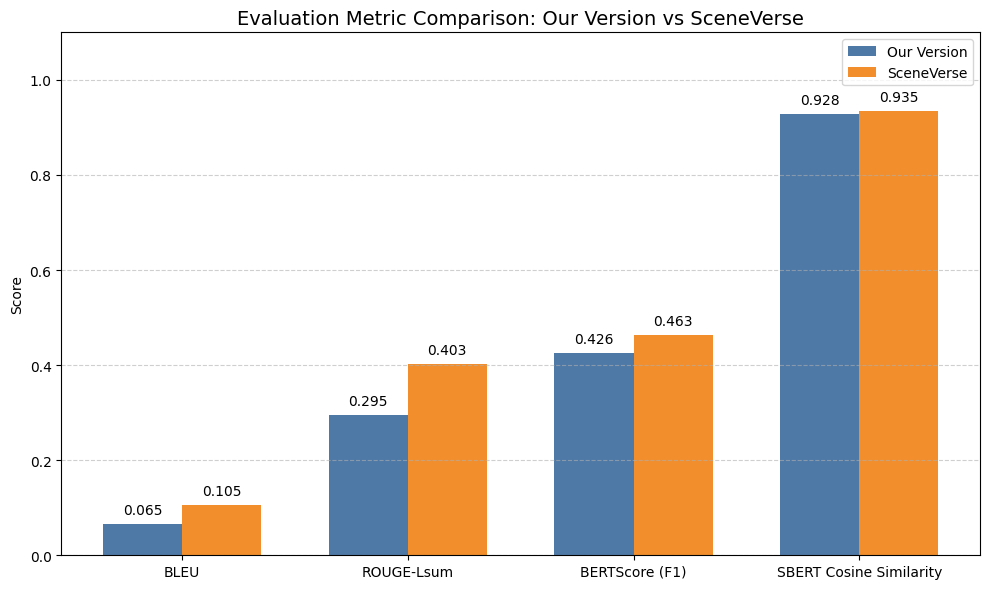

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Metric names
metrics = ["BLEU", "ROUGE-Lsum", "BERTScore (F1)", "SBERT Cosine Similarity"]

# Scores for our candidate (Candidate 1) and SceneVerse (Candidate 2)
candidate_1_scores = [0.0654, 0.2954, 0.4260, 0.9278]
candidate_2_scores = [0.1055, 0.4032, 0.4628, 0.9349]

x = np.arange(len(metrics))  # label locations
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, candidate_1_scores, width, label='Our Version', color='#4E79A7')
bars2 = ax.bar(x + width/2, candidate_2_scores, width, label='SceneVerse', color='#F28E2B')

# Add text labels above the bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Labels, title, legend
ax.set_ylabel('Score')
ax.set_title('Evaluation Metric Comparison: Our Version vs SceneVerse', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


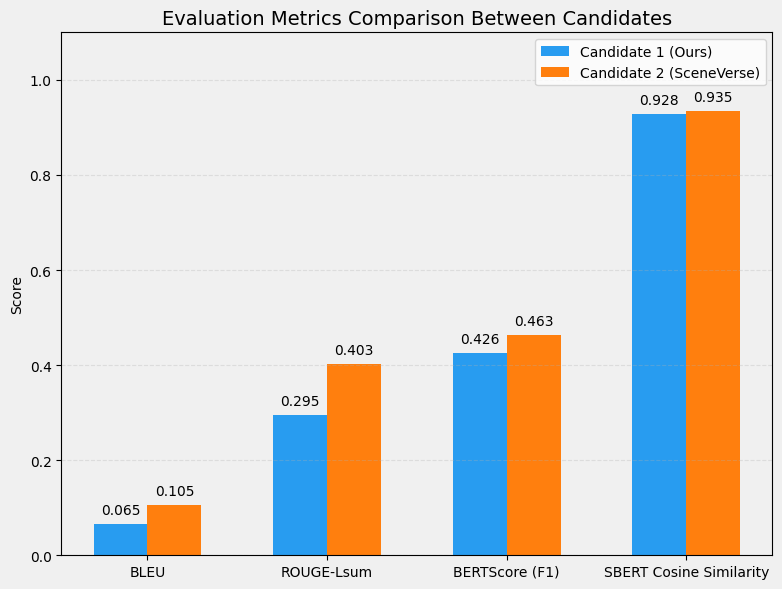

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Metric names
metrics = ["BLEU", "ROUGE-Lsum", "BERTScore (F1)", "SBERT Cosine Similarity"]

# Scores for our candidate (Candidate 1) and SceneVerse (Candidate 2)
candidate_1_scores = [0.0654, 0.2954, 0.4260, 0.9278]
candidate_2_scores = [0.1055, 0.4032, 0.4628, 0.9349]

x = np.arange(len(metrics))  # label locations
width = 0.3  # bar width

# Use the color scheme from the image: orange for Candidate 1, darker orange for Candidate 2
color_c1 = "#289cf0"  # strong blue
color_c2 = "#ff7f0e"  # vivid orange

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#f0f0f0')  # 整个图片背景，例如外边缘
ax.set_facecolor('#f0f0f0')         # 图表内部背景（x、y 轴之间）
bars1 = ax.bar(x - width/2, candidate_1_scores, width, label='Candidate 1 (Ours)', color=color_c1)
bars2 = ax.bar(x + width/2, candidate_2_scores, width, label='Candidate 2 (SceneVerse)', color=color_c2)

# Add text labels above the bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Labels, title, legend
ax.set_ylabel('Score')
ax.set_title('Evaluation Metrics Comparison Between Candidates', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


In [13]:
import json
with open('region_cap.json', 'r') as f:
    region_cap = json.load(f)

In [16]:
print(region_cap['scene_level'])

The apartment is efficiently organized with dedicated areas for storage, work, living, and hygiene. It includes a closet with shelving for kitchenware and clothing, a study with desks and shelves, and a cozy bedroom with beds, storage, and personal items. The modern kitchen features sinks, cooktops, and cabinets, while the bathroom includes toilets, sinks, and shelving for toiletries and cleaning supplies. The layout supports practical, comfortable living.
